In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import pickle

print("Tous les imports sont OK !")

Tous les imports sont OK !


In [3]:
df = pd.read_csv("data/MAL-anime.csv")
print(f"Shape : {df.shape}")
df.head()

Shape : (12774, 10)


,Unnamed: 0,Title,Rank,Type,Episodes,Aired,Members,page_url,image_url,Score
0,0,Net-juu no Susume,1568,TV,10,Oct 2017 - Dec 2017,450968,https://myanimelist.net/anime/36038/Net-juu_no...,https://cdn.myanimelist.net/r/100x140/images/a...,7.55
1,1,Neon Genesis Evangelion: The End of Evangelion,99,Movie,1,Jul 1997 - Jul 1997,883576,https://myanimelist.net/anime/32/Neon_Genesis_...,https://cdn.myanimelist.net/r/100x140/images/a...,8.55
2,2,Templex,11445,Movie,1,2015 - 2015,538,https://myanimelist.net/anime/40721/Templex,https://cdn.myanimelist.net/r/100x140/images/a...,5.29
3,3,s.CRY.ed,2248,TV,26,Jul 2001 - Dec 2001,81283,https://myanimelist.net/anime/168/sCRYed,https://cdn.myanimelist.net/r/100x140/images/a...,7.36
4,4,Toaru Majutsu no Index-tan III,6679,Special,2,Dec 2018 - Apr 2019,11370,https://myanimelist.net/anime/39094/Toaru_Maju...,https://cdn.myanimelist.net/r/100x140/images/a...,6.44


In [4]:
print("=== Infos générales ===")
print(df.info())
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print("\n=== Statistiques descriptives ===")
df[['Score', 'Episodes', 'Members']].describe()


=== Infos générales ===
<class 'pandas.DataFrame'>
RangeIndex: 12774 entries, 0 to 12773
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  12774 non-null  int64  
 1   Title       12774 non-null  str    
 2   Rank        12774 non-null  int64  
 3   Type        12774 non-null  str    
 4   Episodes    12774 non-null  str    
 5   Aired       12774 non-null  str    
 6   Members     12774 non-null  int64  
 7   page_url    12774 non-null  str    
 8   image_url   12774 non-null  str    
 9   Score       12774 non-null  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 3.5 MB
None

=== Valeurs manquantes ===
Unnamed: 0    0
Title         0
Rank          0
Type          0
Episodes      0
Aired         0
Members       0
page_url      0
image_url     0
Score         0
dtype: int64

=== Statistiques descriptives ===


,Score,Members
count,12774.000000,1.277400e+04
mean,6.475332,7.080744e+04
std,0.942195,2.140947e+05
min,1.850000,1.810000e+02
25%,5.840000,1.455000e+03
50%,6.500000,6.566500e+03
75%,7.170000,4.066725e+04
max,9.100000,3.759013e+06


In [7]:
# On garde uniquement les colonnes utiles
cols = ['Type', 'Episodes', 'Members', 'Score']
df_clean = df[cols].copy()

# Suppression des lignes avec des valeurs manquantes
df_clean.dropna(inplace=True)

# Conversion des types
df_clean['Episodes'] = pd.to_numeric(df_clean['Episodes'], errors='coerce')
df_clean.dropna(inplace=True)

# Encodage de la variable catégorielle Type
le = LabelEncoder()
df_clean['Type_encoded'] = le.fit_transform(df_clean['Type'])

print(f"Shape après nettoyage : {df_clean.shape}")
print(f"\nTypes d'animés : {le.classes_}")
df_clean.head()

Shape après nettoyage : (12719, 5)

Types d'animés : ['Movie' 'ONA' 'OVA' 'Special' 'TV' 'Unknown']


,Type,Episodes,Members,Score,Type_encoded
0,TV,10.0,450968,7.55,4
1,Movie,1.0,883576,8.55,0
2,Movie,1.0,538,5.29,0
3,TV,26.0,81283,7.36,4
4,Special,2.0,11370,6.44,3


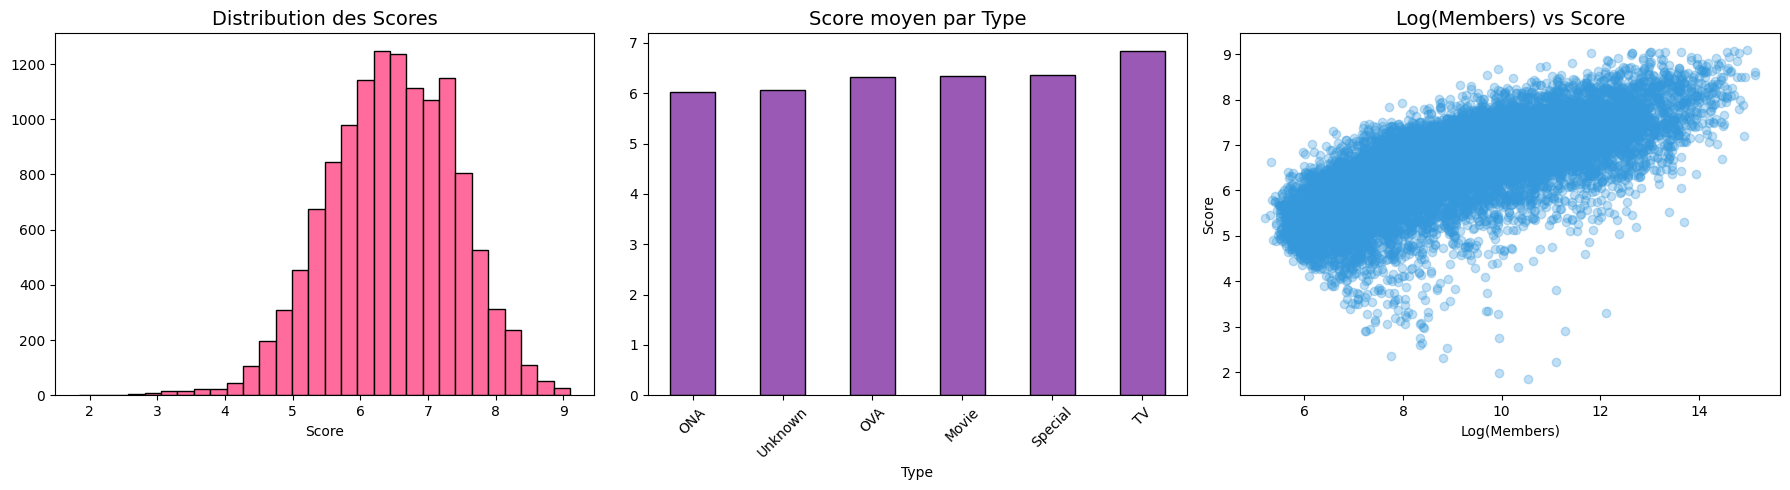

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution du score
axes[0].hist(df_clean['Score'], bins=30, color='#FF6B9D', edgecolor='black')
axes[0].set_title('Distribution des Scores', fontsize=14)
axes[0].set_xlabel('Score')

# Score par Type
df_clean.groupby('Type')['Score'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='#9B59B6', edgecolor='black'
)
axes[1].set_title('Score moyen par Type', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Corrélation Members vs Score
axes[2].scatter(np.log1p(df_clean['Members']), df_clean['Score'], 
                alpha=0.3, color='#3498DB')
axes[2].set_title('Log(Members) vs Score', fontsize=14)
axes[2].set_xlabel('Log(Members)')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
X = df_clean[['Type_encoded', 'Episodes', 'Members']]
y = df_clean['Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (10175, 3) | Test : (2544, 3)


In [13]:
from sklearn.model_selection import GridSearchCV

# Définition des modèles et leurs grilles de paramètres
param_grids = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.5, 1.0]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    },
    "CatBoost": {
        "model": CatBoostRegressor(random_state=42, verbose=0),
        "params": {
            "iterations": [50, 100, 200],
            "depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.3]
        }
    }
}

# GridSearchCV pour chaque modèle
results = []
best_models = {}

for name, config in param_grids.items():
    print(f"🔍 Optimisation de {name}...")
    
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    # Meilleur modèle trouvé
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Evaluation sur le test set
    y_pred = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modèle": name,
        "Meilleurs paramètres": str(grid_search.best_params_),
        "R² CV (train)": round(grid_search.best_score_, 4),
        "RMSE (test)": round(rmse, 4),
        "R² (test)": round(r2, 4)
    })
    
    print(f"   Meilleurs params : {grid_search.best_params_}")
    print(f"   R² CV : {grid_search.best_score_:.4f} | RMSE test : {rmse:.4f} | R² test : {r2:.4f}\n")

# Tableau de comparaison final
results_df = pd.DataFrame(results).sort_values("R² (test)", ascending=False)

print("=" * 60)
print(" CLASSEMENT FINAL DES MODÈLES")
print("=" * 60)
print(results_df[["Modèle", "R² CV (train)", "RMSE (test)", "R² (test)"]].to_string(index=False))

🔍 Optimisation de Decision Tree...


   Meilleurs params : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
   R² CV : 0.5474 | RMSE test : 0.6103 | R² test : 0.5677

🔍 Optimisation de Random Forest...
   Meilleurs params : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
   R² CV : 0.5640 | RMSE test : 0.5987 | R² test : 0.5840

🔍 Optimisation de AdaBoost...
   Meilleurs params : {'learning_rate': 0.01, 'n_estimators': 200}
   R² CV : 0.5234 | RMSE test : 0.6307 | R² test : 0.5382

🔍 Optimisation de XGBoost...
   Meilleurs params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
   R² CV : 0.5792 | RMSE test : 0.5910 | R² test : 0.5946

🔍 Optimisation de LightGBM...
   Meilleurs params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
   R² CV : 0.5795 | RMSE test : 0.5893 | R² test : 0.5969

🔍 Optimisation de CatBoost...
   Meilleurs params : {'depth': 7, 'iterations': 100, 'learning_rate': 0.1}
   R² CV : 0.5837 | RMSE test : 0.5897 | R² test : 0.5963

 CLASSEMENT FIN

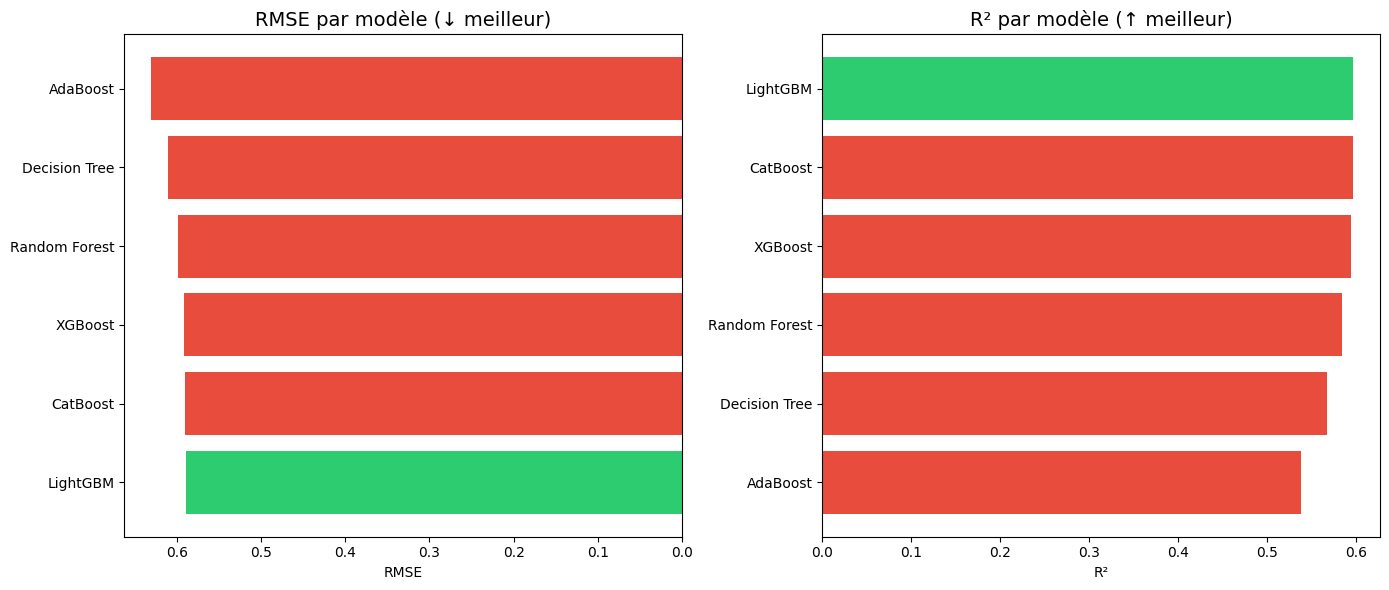

 Graphique de comparaison sauvegardé !


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trier par RMSE croissant pour le graphique
df_plot = results_df.sort_values("RMSE (test)")

# RMSE
colors = ['#2ECC71' if i == 0 else '#E74C3C' for i in range(len(df_plot))]
axes[0].barh(df_plot['Modèle'], df_plot['RMSE (test)'], color=colors)
axes[0].set_title('RMSE par modèle (↓ meilleur)', fontsize=14)
axes[0].set_xlabel('RMSE')
axes[0].invert_xaxis()

# R²
df_plot2 = results_df.sort_values("R² (test)")
colors2 = ['#2ECC71' if i == len(df_plot2)-1 else '#E74C3C' for i in range(len(df_plot2))]
axes[1].barh(df_plot2['Modèle'], df_plot2['R² (test)'], color=colors2)
axes[1].set_title('R² par modèle (↑ meilleur)', fontsize=14)
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique de comparaison sauvegardé !")

In [16]:
# Sélection du meilleur modèle (R² le plus élevé)
best_model_name = results_df.iloc[0]['Modèle']
best_model = best_models[best_model_name]

print(f" Meilleur modèle : {best_model_name}")
print(f"   RMSE : {results_df.iloc[0]['RMSE (test)']}")
print(f"   R²   : {results_df.iloc[0]['R² (test)']}")

# Sauvegarde du modèle et de l'encodeur
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

results_df.to_csv("resultats_modeles.csv", index=False)

print("\n Modèle sauvegardé dans best_model.pkl")
print(" Encodeur sauvegardé dans label_encoder.pkl")
print(" Résultats sauvegardés dans resultats_modeles.csv")

 Meilleur modèle : LightGBM
   RMSE : 0.5893
   R²   : 0.5969

 Modèle sauvegardé dans best_model.pkl
 Encodeur sauvegardé dans label_encoder.pkl
 Résultats sauvegardés dans resultats_modeles.csv
